# Lab 3.2 - Processing Dr. Bergen's Eagle Data with column selectors

Dr. Bergen, Director of the WSU Statistical Consulting Center, has a data processing task for you.  The associated data can be found in the `data` folder of this repository.  

Dr. Bergen had the following to say about the data.

 - One row = one GPS measurement.  
 - Subsample of 10K GPS points from a couple bald eagles in Iowa. 
 - **Context.** need to use the flight characteristics to perform $k$-means clustering of the flight points.  
 
Variables to be used for clustering include

- `KPH` (km per hour; an instantaneous measure of speed; measured by the GPS device);
- `Sn` (an average speed; given 2 time points and at locations and something like );
- `AGL0` (meters above ground level);
- `VerticalRate` (change in AGL between two time points; large negative if descending quickly; large positive if ascending quickly);
- `absVR` (absolute value of VerticalRate); and
- `abs_angle`c(absolute value of turn angle, in radians; larger values equal more “tortuous”, i.e. twisty flight)

All variables except for `VerticalRate` are skewed and all variables need to be mean-centered and standardized prior to clustering.

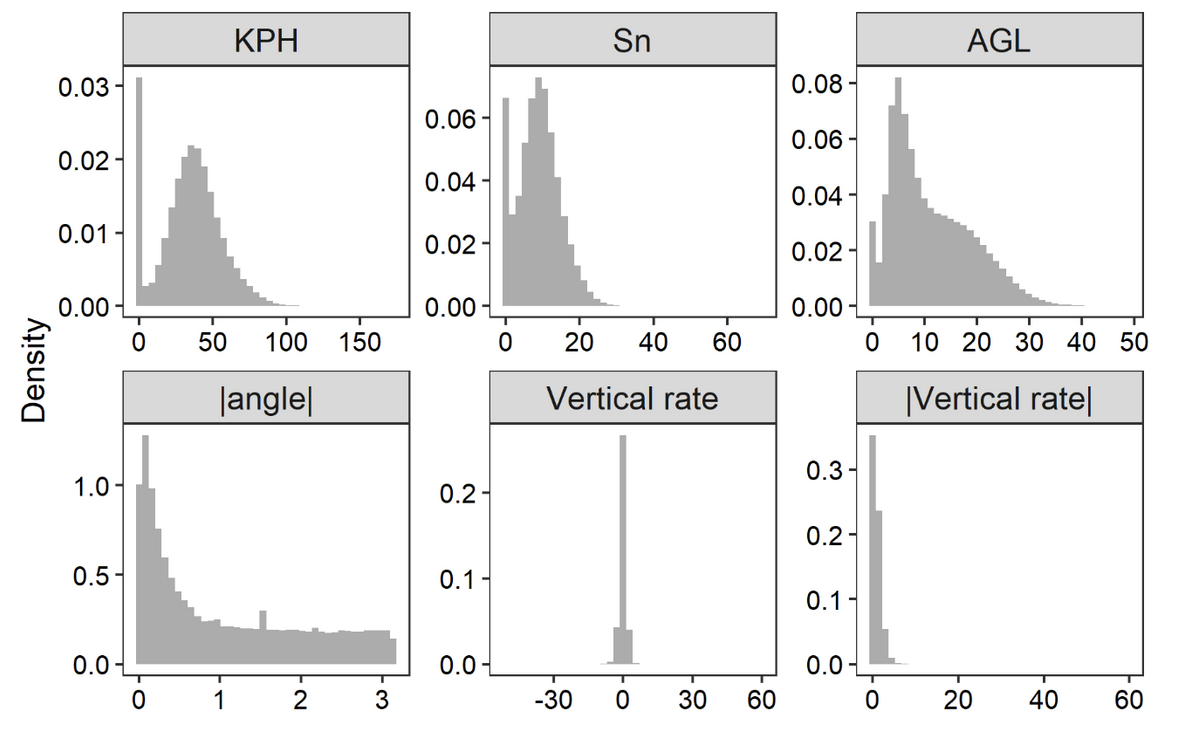

Note that data is 

- *mean-centered* by subtracting the mean of the column from each entry.
- *standardized* by dividing each entry by the standard deviation of the column.
- Together, these two operations are often called *z-scoring*.

### Tasks

You need to use the techniques from this modules lectures to perform the following tasks.

- Apply `sqrt` transform to `KPH`, `Sn`, `AGL0`, `absVR` and `abs_angle` (but not `VerticalRate` due to negative values)
- Mean-center and standardize transformed variables from above as well as `VerticalRate`
- Visualize the transformed features using `plotnine` with a `facet_wrap`.  **HINT.** To make this work, you will need to stack all of the transformed features.

In this lab, you will perform these tasks two ways.  First, you will stack the data and perform the transformations using `polars` windows functions with a partition. Then, you will do the same thing using `polars` without stacking and instead using column selectors.

#### Problem 1

Perform the data management tasks using `polars` windows functions with a partition.  Do this by

1. Stacking the measurement columns into a single column named `value` with a corresponding column named `feature` that indicates the original variable name.
2. Using a `polars` window function with a partition on `feature` to perform the `sqrt` transformation, mean-centering and standardization.

Before we redo the solution using column selectors, please copy your **Problem 3** and **Problem 5** solutions from the previous lab and answer the following questions.

In [3]:
import polars as pl

df = pl.read_csv("data/bald_eagle_subsample.csv")
df.columns


['Animal_ID',
 'Sex',
 'Age2',
 'LocalTime',
 'KPH',
 'Sn',
 'AGL0',
 'VerticalRate',
 'abs_angle',
 'absVR']

In [4]:
# Your solution to problem 1 here (single dot-chain using assignment expression).

# import polars as pl
# Load dataset
df = pl.read_csv("data/bald_eagle_subsample.csv")

# Melt measurement columns into long format
df_long = df.melt(
    id_vars=["Animal_ID", "Sex", "Age2", "LocalTime"],   # keep identifiers
    value_vars=["KPH", "Sn", "AGL0", "VerticalRate", "abs_angle", "absVR"],  # stack these
    variable_name="feature",
    value_name="value"
)

df_long.head()



C:\Users\im4284hw\AppData\Local\Temp\ipykernel_21208\452275376.py:8: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`


Animal_ID,Sex,Age2,LocalTime,feature,value
i64,str,str,str,str,f64
105,"""F""","""Fledgling""","""7/4/19 9:01""","""KPH""",32.81
105,"""F""","""Fledgling""","""7/4/19 9:01""","""KPH""",29.63
106,"""F""","""Fledgling""","""7/6/19 7:02""","""KPH""",35.42
106,"""F""","""Fledgling""","""7/6/19 7:02""","""KPH""",32.87
106,"""F""","""Fledgling""","""7/6/19 7:02""","""KPH""",35.37


#### Problem 2

Redo the data management tasks using `polars` windows functions with a partition.  Do this by using column selectors to select the measurement columns and perform the `sqrt` transformation, mean-centering and standardization WITHOUT stacking the data.


In [28]:
import polars as pl
import polars.selectors as cs

# === Load data ===
eagle = pl.read_csv("data/bald_eagle_subsample.csv")

# === Select numeric measurement columns ===
measurement_cols = cs.numeric()

# === Transformations: sqrt (nonnegative only), mean-center, standardize ===
(
    eagle_transformed := (
        eagle
        .with_columns([
            # Square root only on nonnegative values (negatives clipped to 0)
            pl.col(c).clip(0, None).sqrt().alias(f"{c}_sqrt")
            for c in eagle.select(measurement_cols).columns
        ])
        .with_columns([
            # Mean-center (global)
            (pl.col(f"{c}_sqrt") - pl.col(f"{c}_sqrt").mean())
            .alias(f"{c}_centered")
            for c in eagle.select(measurement_cols).columns
        ])
        .with_columns([
            # Standardize (z-score)
            ((pl.col(f"{c}_sqrt") - pl.col(f"{c}_sqrt").mean()) / pl.col(f"{c}_sqrt").std())
            .alias(f"{c}_z")
            for c in eagle.select(measurement_cols).columns
        ])
    )
)

# === Quick preview of standardized columns ===
eagle_transformed.select(cs.ends_with("_z")).head()


Animal_ID_z,KPH_z,Sn_z,AGL0_z,VerticalRate_z,abs_angle_z,absVR_z
f64,f64,f64,f64,f64,f64,f64
-70.700071,-0.672224,-0.957445,-1.874878,-0.911564,-1.697594,-2.083444
-70.700071,-0.920741,-0.712885,-1.895064,-0.911564,-0.356132,-1.394379
0.014143,-0.477126,-0.509635,-1.377443,0.389398,0.959536,-0.581851
0.014143,-0.667653,-0.373613,-1.424235,-0.911564,0.22715,-0.648904
0.014143,-0.480794,-0.164236,-1.509927,-0.911564,-0.647365,-0.240543


#### Problem 3

Use `plotnine` to create a plot similar to the one shown above, but with the standardized data, which should result in something similar to the following plot:

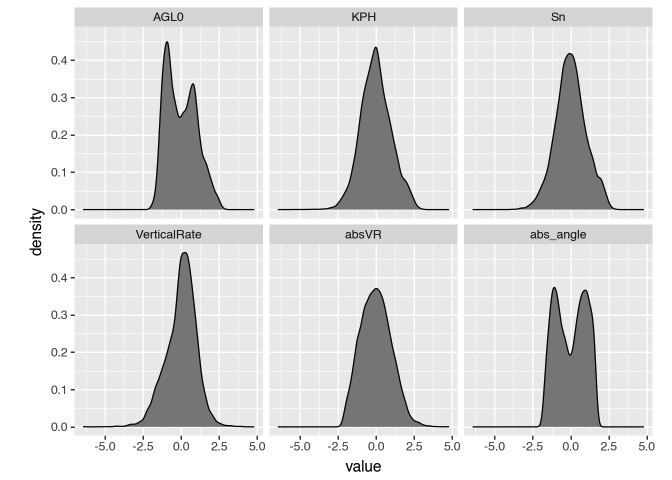

Note that
1. We use `geom_density` and `facet_wrap`, and
2. We set the `fill` to `"grey"`

c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_density : Removed 4629 rows containing non-finite values.
c:\Users\im4284hw\AppData\Local\anaconda3\envs\polars\Lib\site-packages\plotnine\themes\themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


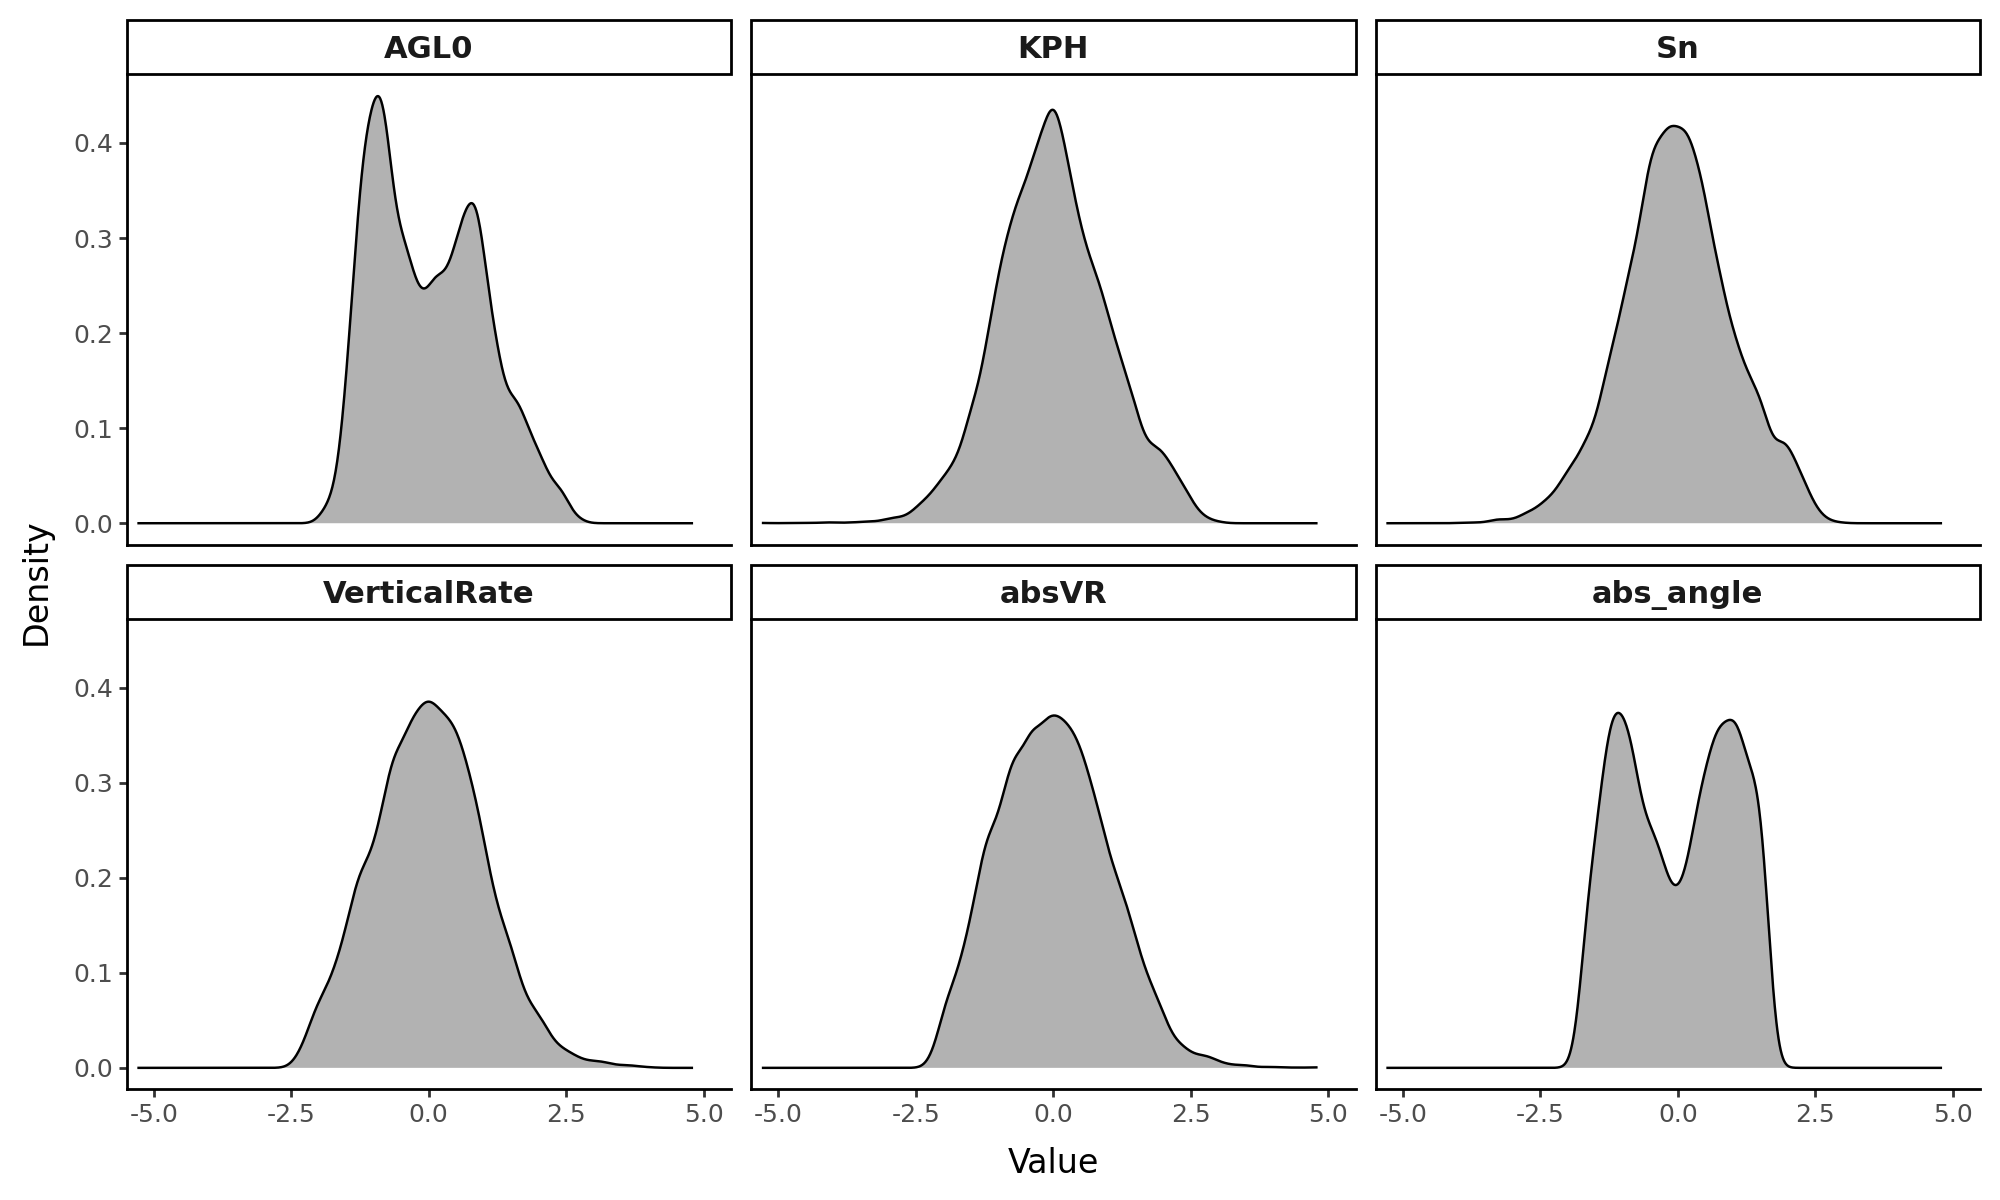

In [ ]:
from plotnine import (
    ggplot, aes, geom_density, facet_wrap, labs,
    theme_classic, theme, element_text, coord_cartesian
)

# Ensure order matches professor's desired facet layout
order = ["AGL0_z", "KPH_z", "Sn_z", "VerticalRate_z", "absVR_z", "abs_angle_z"]

stacked = (
    eagle_transformed
    .select(order)
    .unpivot(variable_name="Variable", value_name="Value")
    .with_columns(
        pl.col("Variable")
        .str.replace("_z$", "")  # cleaner facet labels
    )
)

# Convert to pandas (plotnine requires pandas DataFrame)
stacked_pd = stacked.to_pandas()

p = (
    ggplot(stacked_pd, aes(x="Value"))
    + geom_density(fill="grey", alpha=0.6, color="black")
    + facet_wrap("~Variable", scales="fixed", ncol=3)
    + coord_cartesian(xlim=(-5, 5), ylim=(0, 0.45))
    + labs(
        x="Value",
        y="Density"
    )
    + theme_classic()
    + theme(
        figure_size=(10, 6),
        axis_title=element_text(size=12),
        strip_text=element_text(size=11, weight="bold"),
        plot_title=element_text(size=14, weight="bold", ha="center"),
        # Only show left y-axis labels and bottom x-axis labels
        subplots_adjust={'wspace': 0.25, 'hspace': 0.3},
        axis_text_x=element_text(size=9),
        axis_text_y=element_text(size=9)
    )
)

p
